In [78]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt


In [79]:
frame = cv2.imread("image.png")
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

with open("frog_position.json", "r") as f:
    frog = json.load(f)

frog_pos = (frog["x"], frog["y"])
fx, fy = frog_pos


In [80]:
FROG_RADIUS = 65
BALL_RADIUS = 18
SEARCH_MARGIN = 6
OVERLAP = 8


In [81]:
def create_ring_mask(shape, center, r_inner, r_outer):
    h, w = shape[:2]
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X-center[0])**2 + (Y-center[1])**2)

    mask = np.logical_and(dist >= r_inner, dist <= r_outer)
    return (mask.astype(np.uint8) * 255)


In [82]:
def validate_ball(frame, center, ball_radius=16):
    x, y = center

    roi = frame[y-ball_radius:y+ball_radius,
                x-ball_radius:x+ball_radius]

    if roi.size == 0:
        return False

    hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)

    sat_ratio = np.mean(hsv[:,:,1] > 80)

    return sat_ratio > 0.30


In [83]:
def detect_mouth_ball(frame, frog_pos):
    fx, fy = frog_pos

    hsv = cv2.cvtColor(frame, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    ring_mask = create_ring_mask(
        frame.shape,
        frog_pos,
        r_inner=FROG_RADIUS - OVERLAP,
        r_outer=FROG_RADIUS + BALL_RADIUS
    )

    color_mask = (s > 80).astype(np.uint8) * 255

    frog_green = ((h > 35) & (h < 85))
    color_mask[frog_green] = 0

    final_mask = cv2.bitwise_and(color_mask, ring_mask)

    kernel = np.ones((5,5), np.uint8)
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN, kernel)
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(
        final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    cnt = max(contours, key=cv2.contourArea)

    M = cv2.moments(cnt)
    if M["m00"] == 0:
        return None

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    if not validate_ball(frame, (cx, cy)):
        return None

    return (cx, cy)


In [84]:
def detect_ball_color(frame, center):
    x, y = center
    roi = frame[y-BALL_RADIUS:y+BALL_RADIUS, x-BALL_RADIUS:x+BALL_RADIUS]

    hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)
    h, s, v = np.mean(hsv.reshape(-1,3), axis=0)

    if s < 60:
        return "Unknown"

    if h < 10 or h > 170:
        return "Red"
    elif h < 30:
        return "Orange"
    elif h < 45:
        return "Yellow"
    elif h < 85:
        return "Green"
    elif h < 130:
        return "Blue"
    else:
        return "Purple"


Ball: Yellow


(np.float64(-0.5), np.float64(912.5), np.float64(699.5), np.float64(-0.5))

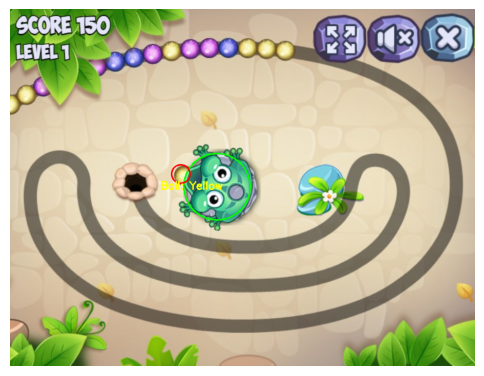

In [86]:
vis = frame.copy()

cv2.circle(vis, frog_pos, FROG_RADIUS, (0,255,0), 2)

ball_center = detect_mouth_ball(frame, frog_pos)

if ball_center:
    color = detect_ball_color(frame, ball_center)

    print(f"Ball: {color}")

    cv2.circle(vis, ball_center, BALL_RADIUS, (255,0,0), 2)
    cv2.putText(
        vis,
        f"Ball: {color}",
        (ball_center[0]-40, ball_center[1]+30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,255,0),
        2
    )
else:
    print("Ball not detected")

plt.figure(figsize=(6,6))
plt.imshow(vis)
plt.axis("off")
